In [17]:
import sys
from ase import Atoms
import numpy as np
from pathlib import Path
import os
from ase.build import bulk
from ase.optimize import BFGS
from ase.visualize import view
from mace.calculators import mace_mp
from ase.build import graphene
from ase.build import bulk
from ase.calculators.emt import EMT
import json
print("PYTHON:", sys.executable)

# get rid of the future warning
import warnings 
warnings.filterwarnings(
    "ignore",
    message=r"You are using `torch.load` with `weights_only=False`.*",
    category=FutureWarning,
)



PYTHON: c:\Users\rnpla\anaconda3\envs\mace_phonons\python.exe


In [18]:
import numpy as np
from ase.io import read
from ase.build import make_supercell
from ase import Atoms
from ase.visualize import view


# load the unit cell from materials projet:
# the BN.poscar was found here: 
# https://next-gen.materialsproject.org/materials/mp-984?formula=BN
# the materials project defaults to exporting .poscar to be read by vasp 

#atoms = read(r"C:\Users\rnpla\Desktop\2026\mlip_phonons\input_files\BN.poscar")
#atoms = read(r"C:\Users\rnpla\Desktop\2026\mlip_phonons\input_files\C.poscar")
from ase.build import bulk
atoms = bulk('C', 'diamond', a=3.567) # Pure diamond reference

supercell_matrix = np.diag([1,1,1])

supercell = make_supercell(atoms, supercell_matrix)

def place_nv_diamond(atoms):
    # 1. Grab scaled positions and symbols
    frac = atoms.get_scaled_positions(wrap=True)
    symbols = np.array(atoms.get_chemical_symbols())
    c_inds = np.where(symbols == 'C')[0]
    
    # 2. Identify the Carbon closest to the center to be our Nitrogen
    dm = frac[c_inds] - 0.5
    dm -= np.round(dm)
    n_idx = c_inds[np.argmin(np.linalg.norm(dm, axis=1))]
    
    # 3. Find its nearest neighbor to become the Vacancy
    # get_distances is much cleaner than manual norm for bulk
    dists = atoms.get_distances(n_idx, c_inds, mic=True)
    
    # Ignore the atom itself (distance 0) to find the neighbor
    dists[c_inds == n_idx] = np.inf
    v_idx = c_inds[np.argmin(dists)]
    
    # 4. Apply changes
    atoms[n_idx].symbol = 'N'
    # Use pop for the vacancy so the index shifts are handled by ASE
    atoms.pop(v_idx)
    
    print(f"NV Center: N placed at {n_idx}, Vacancy created at {v_idx}")
    return atoms

def place_cc_dimer_hbn(atoms):
    
    frac = atoms.get_scaled_positions(wrap=True)
    symbols = np.array(atoms.get_chemical_symbols())
    
    # Find the Boron closest to the fractional center (0.5, 0.5, 0.5)
    b_inds = np.where(symbols == 'B')[0]
    dm = frac[b_inds] - 0.5
    dm -= np.round(dm) # Minimum Image Convention 
    iB = b_inds[np.argmin(np.linalg.norm(dm, axis=1))]
    
    # 3. Find the closest Nitrogen in the same plane
    n_inds = np.where(symbols == 'N')[0]
    # Filter for same z-layer
    same_layer = n_inds[np.isclose(frac[n_inds, 2], frac[iB, 2], atol=1e-4)]
    
    # Find bond partner using MIC distances in Cartesian space
    d_bn = frac[same_layer] - frac[iB]
    d_bn -= np.round(d_bn)
    d_cart = d_bn @ atoms.cell
    iN = same_layer[np.argmin(np.linalg.norm(d_cart, axis=1))]
    
    # 4. Swap to Carbon
    atoms[iB].symbol = 'C'
    atoms[iN].symbol = 'C'
    
    print(f"hBN Dimer: Replaced B[{iB}] and N[{iN}]")
    return atoms

#supercell = place_cc_dimer_hbn(supercell)
#supercell = place_nv_diamond(supercell)

# add the vacuum gap if we are dealing with monolayer version of hBN. 
#supercell.center(vacuum=20, axis=2)

#supercell = supercell[np.argsort(supercell.get_chemical_symbols())]
#view(supercell)


In [19]:
from ase.calculators.emt import EMT
from mace.calculators import mace_mp

# the calculator
mace_model = "small-omat-0"
mlip_calc = mace_mp(model=mace_model, device="cuda", default_dtype="float64")

# attach calculator
supercell.calc = mlip_calc

# relax the structure
print("Starting structure relaxation...")
supercell_notrelaxed = supercell.copy()
opt = BFGS(supercell, trajectory='defect_relax.traj')
# fmax=0.01 is a good standard for phonons
opt.run(fmax=0.01) 
view(supercell)
print("Relaxation complete.")

Using model under Academic Software License (ASL) license, see https://github.com/gabor1/ASL 
 To use this model you accept the terms of the license.
Using Materials Project MACE for MACECalculator with C:\Users\rnpla\.cache\mace/maceomat0smallmodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
Using head omat_pbe out of ['omat_pbe']
Starting structure relaxation...
      Step     Time          Energy          fmax
BFGS:    0 16:05:48      -18.022687        0.000000
Relaxation complete.


WARNING, 2 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 4.682e-07*i)
WARNING, 2 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 4.682e-07*i)


C:\jltmp\ipykernel_27864\938543329.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{t * unit_conversion:.0f}" for t in ticks])


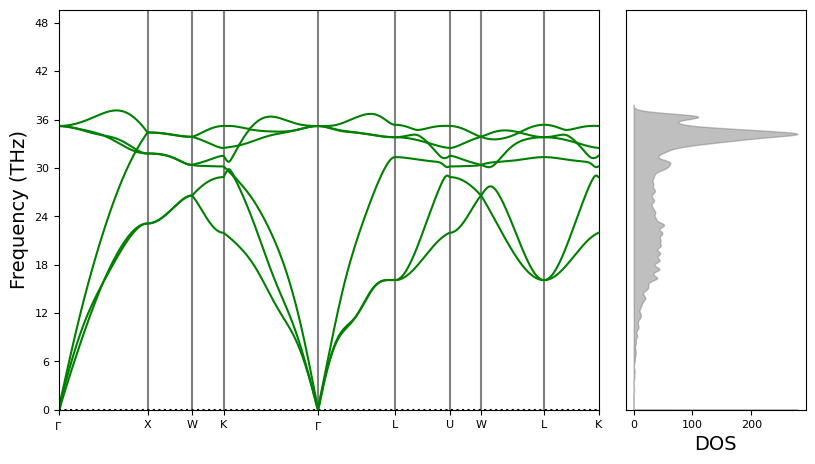

In [ ]:
from ase.build import bulk
from ase.phonons import Phonons
import matplotlib.pyplot as plt
import shutil

# ———————————— params 

phonon_name = 'nv_diamond' 
#phonon_name = 'hbn_c2'
# k-point path for structure

# AFLOW Standard Paths, taken from W. Setyawan and S. Curtarolo https://www.sciencedirect.com/science/article/pii/S0927025610002697 
# Diamond (fcc)
# G-X-W-K-G-L-U-W-L-K; U-X (';' is a jump)
if True: 
    points = {
        'G': [0.0, 0.0, 0.0],
        'X': [0.5, 0.0, 0.5],
        'W': [0.5, 0.25, 0.75],
        'K': [0.375, 0.375, 0.75],
        'L': [0.5, 0.5, 0.5],
        'U': [0.625, 0.25, 0.625]
    }
if False: 
    # hBN (HEX)
    # G-M-K-G-A-L-H-A
    # this can be used for the monolayer, as that is simply GMKG
    points = {
        'G': [0.0, 0.0, 0.0],
        'M': [0.5, 0.0, 0.0],
        'K': [1/3, 1/3, 0.0],
        'A': [0.0, 0.0, 0.5],
        'L': [0.5, 0.0, 0.5],
        'H': [1/3, 1/3, 0.5]
    }

#k_path = "GMKG" # hbn monolayer
#k_path = "GMKGALHA" # hbn bulk 
k_path = "GXWKGLUWLK" # diamond
#———————————— end Params.


#———————————— now get phonons
# clear the name from cache so 'Phonons' does not get confused.
if os.path.exists(phonon_name):
    shutil.rmtree(phonon_name)

# we input the inbuilt supercell
ph = Phonons(supercell, mlip_calc, supercell=(4, 4, 4), delta=0.01, name = phonon_name)
ph.run()
ph.read(acoustic=True)
ph.clean()

path = atoms.cell.bandpath(k_path, npoints=400, special_points=points)
bs = ph.get_band_structure(path)
dos = ph.get_dos(kpts=(20, 20, 20)).sample_grid(npts=500, width=1e-3)

# Plotting logic
fig = plt.figure(figsize=(9, 5))

# convert to thz 
unit_conversion = 241.798
emax_thz = 50.0 
emax_ev = emax_thz / unit_conversion

# Band Structure Axis
ax = fig.add_axes([0.12, 0.1, 0.60, 0.8])
bs.plot(ax=ax, emin=0.0, emax=emax_ev)

# Convert Y-ticks to THz for readability
ticks = ax.get_yticks()
ax.set_yticklabels([f"{t * unit_conversion:.0f}" for t in ticks])
ax.set_ylabel("Frequency (THz)", fontsize=14)

# DOS Axis
dosax = fig.add_axes([0.75, 0.1, 0.20, 0.8])
dosax.fill_between(
    dos.get_weights(),
    dos.get_energies() * unit_conversion, # Scale energies to THz
    y2=0,
    color='grey', alpha=0.5
)

dosax.set_ylim(0, emax_thz) # Now using the THz ceilings
dosax.set_yticks([])
dosax.set_xlabel('DOS', fontsize=14)

fig.savefig(f'{phonon_name}_Phonon.png', dpi=300)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EV_TO_THz = 241.79893          # 1 eV = 241.79893 THz (E = h nu)
THz_TO_CM1 = 33.35641           # 1 THz ≈ 33.35641 cm^-1

def compute_phonon_dos(ph, kpts=(12, 12, 12), npts=4000, width_thz=0.25):
    """
    Returns (freqs_thz, dos_states_per_thz).

    ph: an ASE Phonons object AFTER ph.run() and ph.read(...)
    kpts: Monkhorst-Pack grid used for DOS integration over the BZ
    width_thz: Gaussian broadening in THz (more intuitive than eV)
    """
    width_ev = width_thz / EV_TO_THz

    dos = ph.get_dos(kpts=kpts).sample_grid(npts=npts, width=width_ev)

    energies_ev = np.asarray(dos.get_energies())
    weights_per_ev = np.asarray(dos.get_weights())

    # Convert to frequency axis
    freqs_thz = energies_ev * EV_TO_THz

    # If plotting vs THz, convert DOS units: g(ν) = g(E) * dE/dν = g(E) / (dν/dE) = g(E) / EV_TO_THz
    weights_per_thz = weights_per_ev / EV_TO_THz

    # Guard against tiny negative frequencies (numerical noise)
    mask = freqs_thz >= -1e-6
    freqs_thz = freqs_thz[mask]
    weights_per_thz = weights_per_thz[mask]
    freqs_thz = np.clip(freqs_thz, 0.0, None)

    return freqs_thz, weights_per_thz


def plot_phonon_dos(freqs_thz, dos_states_per_thz, out_png,
                    title=None, emax_thz=None, dpi=450):
    """
    High-quality single-panel DOS plot: DOS on x-axis, frequency on y-axis (THz),
    with a secondary y-axis in cm^-1.
    """
    if emax_thz is None:
        emax_thz = float(np.max(freqs_thz)) * 1.02

    fig, ax = plt.subplots(figsize=(4.6, 6.2), constrained_layout=True)

    # Curve + filled area (no explicit color set; matplotlib defaults)
    ax.plot(dos_states_per_thz, freqs_thz, linewidth=1.2)
    ax.fill_betweenx(freqs_thz, 0.0, dos_states_per_thz, alpha=0.25)

    ax.set_xlabel("Phonon DOS (states / THz)")
    ax.set_ylabel("Frequency (THz)")
    ax.set_ylim(0.0, emax_thz)
    ax.set_xlim(left=0.0)

    ax.grid(True, which="both", alpha=0.25)
    ax.tick_params(direction="in", top=True, right=True)

    if title:
        ax.set_title(title)

    # Secondary axis in cm^-1
    ax2 = ax.twinx()
    y0, y1 = ax.get_ylim()
    ax2.set_ylim(y0 * THz_TO_CM1, y1 * THz_TO_CM1)
    ax2.set_ylabel(r"Frequency (cm$^{-1}$)")
    ax2.tick_params(direction="in", top=True, right=True)

    fig.savefig(out_png, dpi=dpi)
    plt.close(fig)


# ------------------------
#Example usage (after your phonons are computed):

ph.run()
ph.read(acoustic=True)

freqs_thz, g_thz = compute_phonon_dos(ph, kpts=(12,12,12), npts=5000, width_thz=0.25)
plot_phonon_dos(freqs_thz, g_thz,
                out_png=f"{phonon_name}_DOS.png",
                title=f"{phonon_name} phonon DOS | k={12}^3 | σ=0.25 THz",
                emax_thz=50.0)
# ------------------------
